In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind,f_oneway,chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,classification_report
import warnings
import joblib

In [3]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline


In [4]:
df = pd.read_csv('cancer issue.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (17686, 16)


,PatientID,Age,Gender,Race/Ethnicity,BMI,SmokingStatus,FamilyHistory,CancerType,Stage,TumorSize,TreatmentType,TreatmentResponse,SurvivalMonths,Recurrence,GeneticMarker,HospitalRegion
0,1,80,Female,Other,23.3,Smoker,Yes,Breast,II,1.7,Combination Therapy,No Response,103,Yes,NaN,South
1,2,76,Male,Caucasian,22.4,Former Smoker,Yes,Colon,IV,4.7,Surgery,No Response,14,Yes,BRCA1,West
2,3,69,Male,Asian,21.5,Smoker,Yes,Breast,III,8.3,Combination Therapy,Complete Remission,61,Yes,BRCA1,West
3,4,77,Male,Asian,30.4,Former Smoker,Yes,Prostate,II,1.7,Radiation,Partial Remission,64,No,KRAS,South
4,5,89,Male,Caucasian,20.9,Smoker,Yes,Lung,IV,7.4,Radiation,No Response,82,Yes,KRAS,South


In [5]:
df.shape

(17686, 16)

In [6]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Race/Ethnicity', 'BMI', 'SmokingStatus',
       'FamilyHistory', 'CancerType', 'Stage', 'TumorSize', 'TreatmentType',
       'TreatmentResponse', 'SurvivalMonths', 'Recurrence', 'GeneticMarker',
       'HospitalRegion'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          17686 non-null  int64  
 1   Age                17686 non-null  int64  
 2   Gender             17686 non-null  object 
 3   Race/Ethnicity     17686 non-null  object 
 4   BMI                17686 non-null  float64
 5   SmokingStatus      17686 non-null  object 
 6   FamilyHistory      17686 non-null  object 
 7   CancerType         17686 non-null  object 
 8   Stage              17686 non-null  object 
 9   TumorSize          17686 non-null  float64
 10  TreatmentType      17686 non-null  object 
 11  TreatmentResponse  17686 non-null  object 
 12  SurvivalMonths     17686 non-null  int64  
 13  Recurrence         17686 non-null  object 
 14  GeneticMarker      13360 non-null  object 
 15  HospitalRegion     17686 non-null  object 
dtypes: float64(2), int64(3

In [8]:
df.describe()

,PatientID,Age,BMI,TumorSize,SurvivalMonths
count,17686.000000,17686.000000,17686.000000,17686.000000,17686.000000
mean,8843.500000,53.758396,29.253805,5.499751,60.387821
std,5105.652766,21.079473,6.203575,2.603107,34.794859
min,1.000000,18.000000,18.500000,1.000000,1.000000
25%,4422.250000,35.000000,23.900000,3.300000,30.000000
50%,8843.500000,54.000000,29.200000,5.500000,60.000000
75%,13264.750000,72.000000,34.600000,7.700000,91.000000
max,17686.000000,90.000000,40.000000,10.000000,120.000000


In [9]:
df.isnull().sum()

PatientID               0
Age                     0
Gender                  0
Race/Ethnicity          0
BMI                     0
SmokingStatus           0
FamilyHistory           0
CancerType              0
Stage                   0
TumorSize               0
TreatmentType           0
TreatmentResponse       0
SurvivalMonths          0
Recurrence              0
GeneticMarker        4326
HospitalRegion          0
dtype: int64

In [10]:
print("=== Data Information ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())

df['GeneticMarker']= df['GeneticMarker'].fillna('Unknown')
print("✅ Missing values in GeneticMarker filled with 'Unknown'")

=== Data Information ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17686 entries, 0 to 17685
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          17686 non-null  int64  
 1   Age                17686 non-null  int64  
 2   Gender             17686 non-null  object 
 3   Race/Ethnicity     17686 non-null  object 
 4   BMI                17686 non-null  float64
 5   SmokingStatus      17686 non-null  object 
 6   FamilyHistory      17686 non-null  object 
 7   CancerType         17686 non-null  object 
 8   Stage              17686 non-null  object 
 9   TumorSize          17686 non-null  float64
 10  TreatmentType      17686 non-null  object 
 11  TreatmentResponse  17686 non-null  object 
 12  SurvivalMonths     17686 non-null  int64  
 13  Recurrence         17686 non-null  object 
 14  GeneticMarker      13360 non-null  object 
 15  HospitalRegion     17686 non-null  object 
dt

In [13]:
def descriptive_stats(data):
    if isinstance(data,pd.Series):
        data = data.values
        stats_dict = {
        'count': len(data),
        'mean': np.mean(data),
        'median': np.median(data),
        'std': np.std(data, ddof=1),
        'min' : np.min(data),
        'max' : np.max(data),                       
        'q1' : np.percentile(data, 25),
        'q3' : np.percentile(data, 75),
        'iqr' : np.percentile(data, 75) - np.percentile(data, 25),
        'skewness' : stats.skew(data),
        'kurtosis' : stats.kurtosis(data)
        }
    return pd.Series(stats_dict)

print("Descriptive Statistics for SurvivalMonths:")
print(descriptive_stats(df['SurvivalMonths']))

df.describe()

Descriptive Statistics for SurvivalMonths:
count       17686.000000
mean           60.387821
median         60.000000
std            34.794859
min             1.000000
max           120.000000
q1             30.000000
q3             91.000000
iqr            61.000000
skewness        0.010978
kurtosis       -1.214212
dtype: float64


,PatientID,Age,BMI,TumorSize,SurvivalMonths
count,17686.000000,17686.000000,17686.000000,17686.000000,17686.000000
mean,8843.500000,53.758396,29.253805,5.499751,60.387821
std,5105.652766,21.079473,6.203575,2.603107,34.794859
min,1.000000,18.000000,18.500000,1.000000,1.000000
25%,4422.250000,35.000000,23.900000,3.300000,30.000000
50%,8843.500000,54.000000,29.200000,5.500000,60.000000
75%,13264.750000,72.000000,34.600000,7.700000,91.000000
max,17686.000000,90.000000,40.000000,10.000000,120.000000


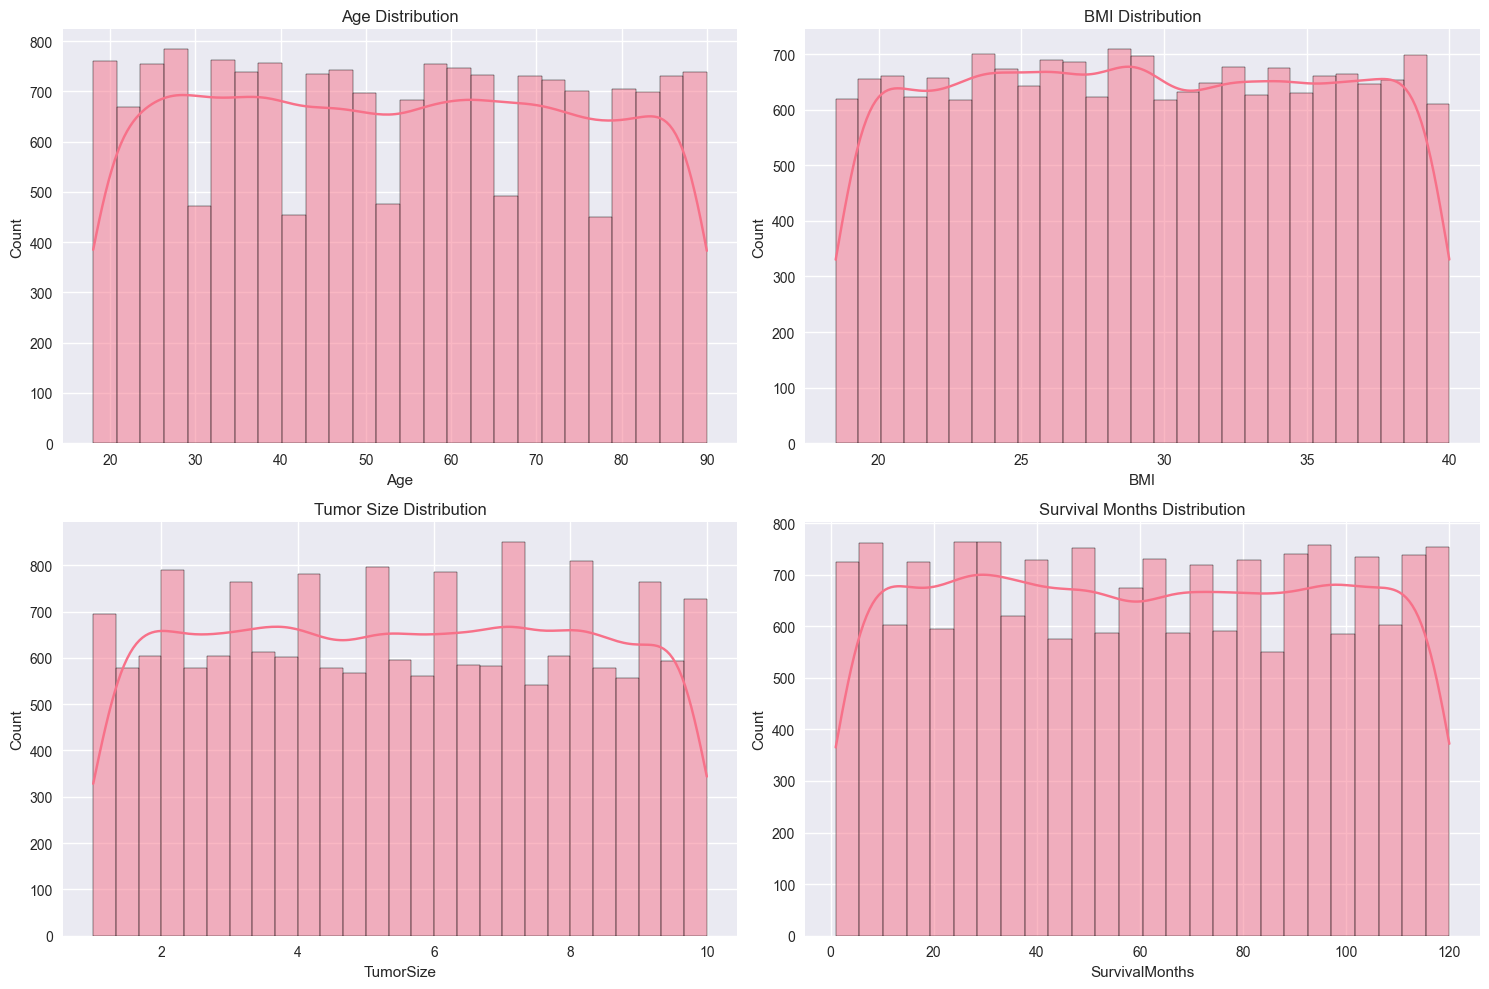

In [17]:
#Distribution Plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(df['Age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(df['BMI'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('BMI Distribution')

sns.histplot(df['TumorSize'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Tumor Size Distribution')

sns.histplot(df['SurvivalMonths'], kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Survival Months Distribution')

plt.tight_layout()
plt.show()

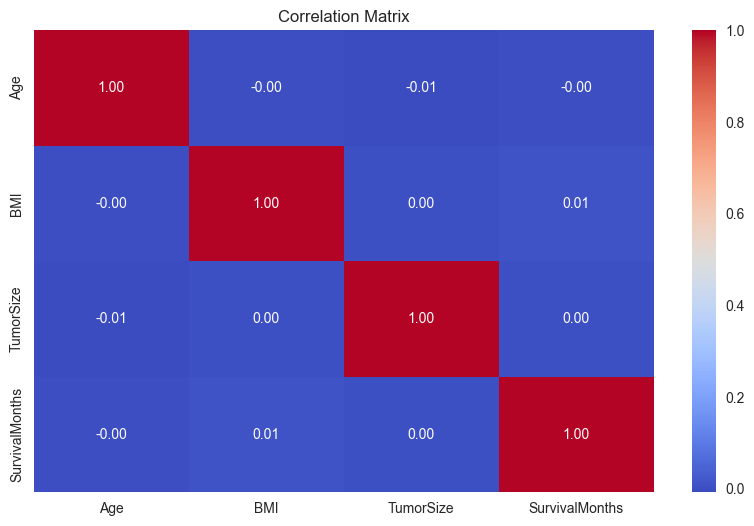

In [19]:
plt.figure(figsize=(10, 6))
numeric_df = df[['Age','BMI','TumorSize','SurvivalMonths']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [20]:
print("=== 1. T-Test: Age by Gender ===")
male_age = df[df['Gender'] == 'Male']['Age']
female_age = df[df['Gender'] == 'Female']['Age']
t_stat, p_val = ttest_ind(male_age, female_age)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_val:.4f}")

print("\n=== 2. ANOVA: Survival by Cancer Type ===")
groups = [group['SurvivalMonths'].values for name, group in df.groupby('CancerType')]
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, P-value: {p_val:.4f}")

print("\n=== 3. Chi-Square Test ===")
contingency = pd.crosstab(df['Recurrence'], df['TreatmentResponse'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.4f}, P-value: {p:.4f}")

=== 1. T-Test: Age by Gender ===
T-statistic: -1.0021, P-value: 0.3163

=== 2. ANOVA: Survival by Cancer Type ===
F-statistic: 0.5610, P-value: 0.7300

=== 3. Chi-Square Test ===
Chi-square: 0.5514, P-value: 0.7590


In [23]:
# Regression: Predict SurvivalMonths
X = pd.get_dummies(df.drop(['PatientID', 'SurvivalMonths', 'Recurrence'], axis=1), drop_first=True)
y = df['SurvivalMonths']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

print("=== Regression Results ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Save model
joblib.dump(reg_model, 'survival_regression_model.pkl')
print("✅ Model saved as 'survival_regression_model.pkl'")

=== Regression Results ===
R² Score: -0.0028
RMSE: 34.72
✅ Model saved as 'survival_regression_model.pkl'


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [26]:
# Classification: Predict Recurrence
X = pd.get_dummies(df.drop(['PatientID', 'Recurrence', 'SurvivalMonths'], axis=1), drop_first=True)
y = df['Recurrence'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)
y_pred = clf_model.predict(X_test)

print("=== Classification Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

joblib.dump(clf_model, 'recurrence_classifier_model.pkl')
print("✅ Model saved as 'recurrence_classifier_model.pkl'")

=== Classification Results ===
Accuracy: 0.4972
              precision    recall  f1-score   support

           0       0.49      0.53      0.51      1738
           1       0.51      0.46      0.48      1800

    accuracy                           0.50      3538
   macro avg       0.50      0.50      0.50      3538
weighted avg       0.50      0.50      0.50      3538

✅ Model saved as 'recurrence_classifier_model.pkl'


In [28]:

from google.colab import files
files.download('survival_regression_model.pkl')
files.download('recurrence_classifier_model.pkl')

ModuleNotFoundError: No module named 'google'